<a href="https://colab.research.google.com/github/PrasastiBaitharu/ybi_foundation/blob/main/YBI_45_DAY_INTERNSHIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Student Career Prediction and Skill Recommendation System

### YBI Foundation Internship — Self Project

## Project Overview

This project aims to develop a machine learning-based system that analyzes student academic information and extracurricular/academic activity data to predict suitable career categories.

After predicting a career category, the system uses career-related information to identify relevant skills and activities that can help the student understand areas for further development.

The project follows the complete machine learning workflow:

- Data collection
- Data understanding
- Data preprocessing
- Exploratory Data Analysis
- Feature engineering
- Model training
- Model evaluation
- Model comparison
- Experimentation
- Career prediction
- Skill recommendation

## Problem Statement

Students participate in different academic and extracurricular activities, but it can be difficult to understand how their interests and performance relate to possible career paths.

This project explores whether machine learning can use student and activity-related information to predict a suitable career category and provide supporting skill recommendations.

## Objectives

1. Understand and analyze student and activity data.
2. Clean and preprocess the datasets.
3. Create meaningful features from student activities.
4. Build machine learning classification models.
5. Compare multiple classification algorithms.
6. Perform experiments by changing relevant parameters.
7. Evaluate model performance using appropriate metrics.
8. Select a final model based on experimental results.
9. Predict career categories for students.
10. Provide career-related skill recommendations.

In [1]:
!git clone https://github.com/narendrar-133/Student-Career-Prediction-System.git

Cloning into 'Student-Career-Prediction-System'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 44 (delta 12), reused 4 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 156.66 KiB | 857.00 KiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
import pandas as pd

base_path = "Student-Career-Prediction-System/dataset/"

student_df = pd.read_csv(base_path + "student.csv")
activity_df = pd.read_csv(base_path + "activity.csv")
career_df = pd.read_csv(base_path + "career.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
print("Student Dataset:", student_df.shape)
print("Activity Dataset:", activity_df.shape)
print("Career Dataset:", career_df.shape)

Student Dataset: (1000, 8)
Activity Dataset: (3496, 8)
Career Dataset: (8, 6)


In [5]:
student_df.head()

,student_id,name,dob,class,board,school,actual_career_id,predicted_career_id
0,1,Katelyn Roberts,2010-03-19,9,ICSE,Turner Group,1,NaN
1,2,Kayla Lucas,2010-07-02,8,ICSE,"Gibson, Smith and Torres",3,NaN
2,3,Rhonda Merritt,2009-10-27,11,ICSE,"Williams, Hull and Anderson",4,NaN
3,4,Erik Chavez,2009-04-29,12,CBSE,Daniels Group,4,NaN
4,5,Megan Anderson,2007-07-28,9,State Board,Ray Ltd,1,NaN


In [6]:
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           1000 non-null   int64  
 1   name                 1000 non-null   object 
 2   dob                  1000 non-null   object 
 3   class                1000 non-null   int64  
 4   board                1000 non-null   object 
 5   school               1000 non-null   object 
 6   actual_career_id     1000 non-null   int64  
 7   predicted_career_id  0 non-null      float64
dtypes: float64(1), int64(3), object(4)
memory usage: 62.6+ KB


In [7]:
student_df.describe(include="all")

,student_id,name,dob,class,board,school,actual_career_id,predicted_career_id
count,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,0.0
unique,NaN,994,713,NaN,3,973,NaN,NaN
top,NaN,Matthew Johnson,2007-07-27,NaN,ICSE,Wilson and Sons,NaN,NaN
freq,NaN,2,5,NaN,334,4,NaN,NaN
mean,500.500000,NaN,NaN,10.004000,NaN,NaN,3.549000,NaN
std,288.819436,NaN,NaN,1.392093,NaN,NaN,2.260688,NaN
min,1.000000,NaN,NaN,8.000000,NaN,NaN,1.000000,NaN
25%,250.750000,NaN,NaN,9.000000,NaN,NaN,2.000000,NaN
50%,500.500000,NaN,NaN,10.000000,NaN,NaN,3.000000,NaN
75%,750.250000,NaN,NaN,11.000000,NaN,NaN,5.000000,NaN


In [8]:
activity_df.head()

,activity_id,student_id,activity_name,category,level,participation,score,year
0,1,1,Physics,Academics,Beginner,Occasional,96,2024
1,2,1,Coding,Academics,Advanced,Regular,95,2023
2,3,1,Economics,Academics,Beginner,Regular,71,2022
3,4,1,Music,Extra-curricular,Beginner,Regular,57,2021
4,5,1,Biology,Academics,Advanced,Occasional,66,2022


In [9]:
activity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3496 entries, 0 to 3495
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   activity_id    3496 non-null   int64 
 1   student_id     3496 non-null   int64 
 2   activity_name  3496 non-null   object
 3   category       3496 non-null   object
 4   level          3496 non-null   object
 5   participation  3496 non-null   object
 6   score          3496 non-null   int64 
 7   year           3496 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 218.6+ KB


In [10]:
activity_df.describe(include="all")

,activity_id,student_id,activity_name,category,level,participation,score,year
count,3496.000000,3496.000000,3496,3496,3496,3496,3496.000000,3496.000000
unique,NaN,NaN,11,3,3,2,NaN,NaN
top,NaN,NaN,Music,Academics,Advanced,Occasional,NaN,NaN
freq,NaN,NaN,335,1573,1215,1775,NaN,NaN
mean,1748.500000,496.656178,NaN,NaN,NaN,NaN,69.188501,2023.005149
std,1009.352598,290.150309,NaN,NaN,NaN,NaN,15.549310,1.394441
min,1.000000,1.000000,NaN,NaN,NaN,NaN,40.000000,2021.000000
25%,874.750000,240.750000,NaN,NaN,NaN,NaN,56.000000,2022.000000
50%,1748.500000,495.500000,NaN,NaN,NaN,NaN,69.000000,2023.000000
75%,2622.250000,749.000000,NaN,NaN,NaN,NaN,82.000000,2024.000000


In [11]:
career_df.head()

,career_id,career_name,career_type,threshold,recommended_activities,required_skills
0,1,Science,Stream,75,"Coding,Mathematics,Biology","Logical thinking,Analysis"
1,2,Commerce,Stream,65,"Economics,Debate,Mathematics","Numerical skills,Communication"
2,3,Arts,Stream,55,"Art,Music,Debate","Creativity,Expression"
3,4,Engineer,Profession,80,"Coding,Mathematics,Physics","Problem solving,Programming"
4,5,Doctor,Profession,85,"Biology,Chemistry","Observation,Discipline"


In [12]:
career_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   career_id               8 non-null      int64 
 1   career_name             8 non-null      object
 2   career_type             8 non-null      object
 3   threshold               8 non-null      int64 
 4   recommended_activities  8 non-null      object
 5   required_skills         8 non-null      object
dtypes: int64(2), object(4)
memory usage: 516.0+ bytes


In [13]:
print("===== STUDENT MISSING VALUES =====")
print(student_df.isnull().sum())

print("\n===== ACTIVITY MISSING VALUES =====")
print(activity_df.isnull().sum())

print("\n===== CAREER MISSING VALUES =====")
print(career_df.isnull().sum())

===== STUDENT MISSING VALUES =====
student_id                0
name                      0
dob                       0
class                     0
board                     0
school                    0
actual_career_id          0
predicted_career_id    1000
dtype: int64

===== ACTIVITY MISSING VALUES =====
activity_id      0
student_id       0
activity_name    0
category         0
level            0
participation    0
score            0
year             0
dtype: int64

===== CAREER MISSING VALUES =====
career_id                 0
career_name               0
career_type               0
threshold                 0
recommended_activities    0
required_skills           0
dtype: int64


In [14]:
print("Student duplicates:", student_df.duplicated().sum())
print("Activity duplicates:", activity_df.duplicated().sum())
print("Career duplicates:", career_df.duplicated().sum())

Student duplicates: 0
Activity duplicates: 0
Career duplicates: 0


In [15]:
student_df["actual_career_id"].value_counts().sort_index()

,count
actual_career_id,
1,215
2,198
3,198
4,82
5,63
6,87
7,77
8,80


In [16]:
career_df[["career_id", "career_name", "career_type"]]

,career_id,career_name,career_type
0,1,Science,Stream
1,2,Commerce,Stream
2,3,Arts,Stream
3,4,Engineer,Profession
4,5,Doctor,Profession
5,6,Chartered Accountant,Profession
6,7,Artist,Profession
7,8,Sports Professional,Profession


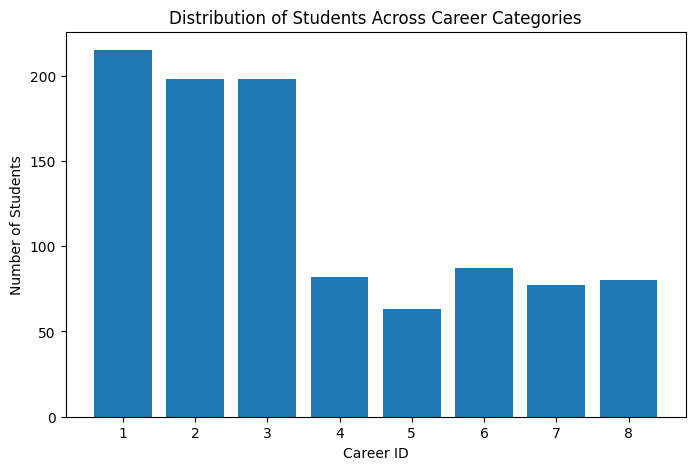

In [17]:
career_counts = student_df["actual_career_id"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    career_counts.index.astype(str),
    career_counts.values
)

plt.title("Distribution of Students Across Career Categories")
plt.xlabel("Career ID")
plt.ylabel("Number of Students")

plt.show()

In [18]:
activity_df["category"].value_counts()

,count
category,
Academics,1573
Extra-curricular,983
Sports,940


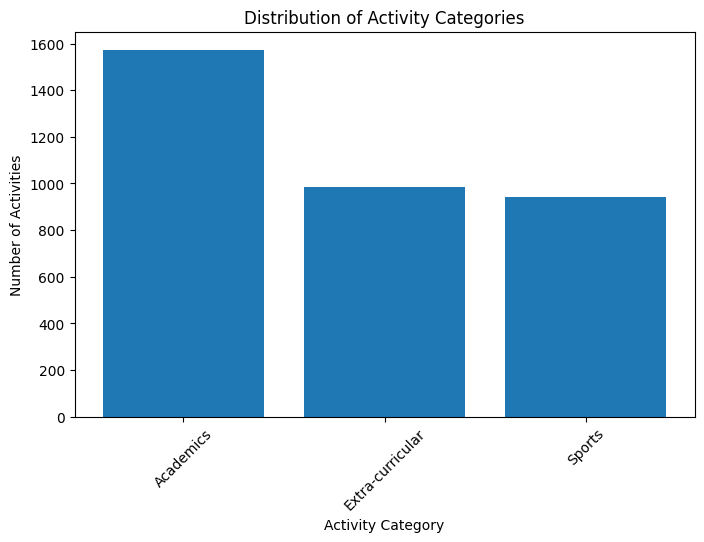

In [19]:
category_counts = activity_df["category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Distribution of Activity Categories")
plt.xlabel("Activity Category")
plt.ylabel("Number of Activities")

plt.xticks(rotation=45)

plt.show()

In [20]:
activity_df["level"].value_counts()

,count
level,
Advanced,1215
Intermediate,1153
Beginner,1128


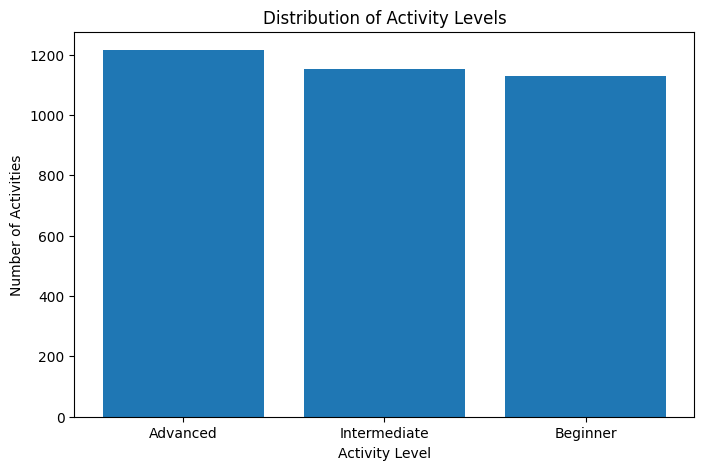

In [21]:
level_counts = activity_df["level"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    level_counts.index,
    level_counts.values
)

plt.title("Distribution of Activity Levels")
plt.xlabel("Activity Level")
plt.ylabel("Number of Activities")

plt.show()

In [22]:
activity_df["participation"].value_counts()

,count
participation,
Occasional,1775
Regular,1721


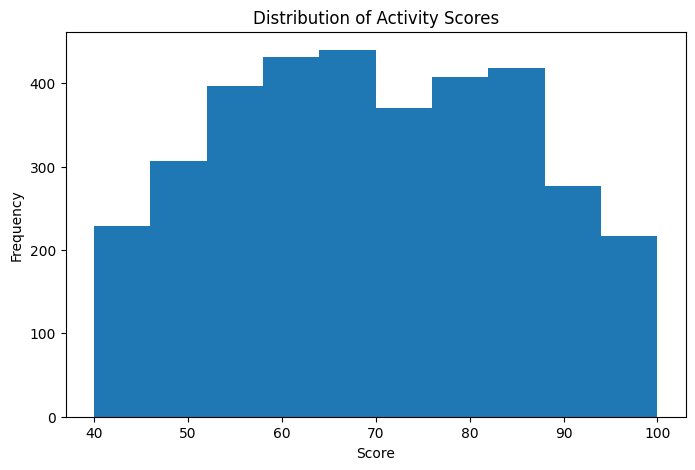

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    activity_df["score"],
    bins=10
)

plt.title("Distribution of Activity Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

In [24]:
student = student_df.copy()
activity = activity_df.copy()
career = career_df.copy()

print("Copies created successfully!")

Copies created successfully!


In [25]:
student["dob"] = pd.to_datetime(student["dob"])

reference_date = pd.Timestamp("2026-01-01")

student["age"] = (
    (reference_date - student["dob"]).dt.days / 365.25
).astype(int)

student[["student_id", "dob", "age"]].head()

,student_id,dob,age
0,1,2010-03-19,15
1,2,2010-07-02,15
2,3,2009-10-27,16
3,4,2009-04-29,16
4,5,2007-07-28,18


In [26]:
student_features = student.drop(
    columns=[
        "name",
        "dob",
        "school",
        "actual_career_id",
        "predicted_career_id"
    ]
)

student_features.head()

,student_id,class,board,age
0,1,9,ICSE,15
1,2,8,ICSE,15
2,3,11,ICSE,16
3,4,12,CBSE,16
4,5,9,State Board,18
